## Problem 1
### Part 1

In [1]:
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff, eye
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import init_printing
init_printing() 

# Define Symbols
t  = symbols("t",   real=True)
l = symbols("l",  real=True)   # Length of Link, assume Links are same length
m = symbols("m", real=True)
k = symbols("k", real=True) # Drag Coefficient
d = symbols("d",real=True)
# Config Variables
x     = Function('x',     real=True)(t)
y     = Function('y',     real=True)(t)
theta = Function('theta', real=True)(t)
a1    = Function('a1',real=True)(t)
a2    = Function('a2',real=True)(t)
## Alpha Kinematics
omega = symbols("omega",real=True)
A1 = symbols("A1",real=True)
A2 = symbols("A2",real=True)
phi = symbols("phi",real=True)


In [2]:
# Defining Various Helper Functions
def cross_matrix(vec):
    
    return Matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return Matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m


In [3]:
# Transform to Joint 1, then Translate to COM 1
T0COM1   = T(R_z(theta), Matrix([[x],[y],[0]]))
#TJ1toCOM1 = T(eye(3), Matrix([[l/2],[0],[0]]))
#T1 = simplify(Tjoint1 @ TJ1toCOM1) # World Frame to COM 1

#T1J1= T(eye(3), Matrix([[-l/2],[0],[0]]))
TJ1rot = T(R_z(pi+a1),Matrix([[-l/2],[0],[0]]))
TJ1COM2 = T(eye(3),Matrix([[l/2],[0],[0]]))
T0COM2= simplify(T0COM1 @ TJ1rot @ TJ1COM2)

#T1J2= T(eye(3),Matrix([[l/2],[0],[0]]))
TJ2rot = (T(R_z(a2),Matrix([[l/2],[0],[0]])))
TJ2COM3 = T(eye(3),Matrix([[l/2],[0],[0]]))
T0COM3= simplify(T0COM1 @  TJ2rot @ TJ2COM3)
##


In [4]:
T0COM1

⎡cos(θ(t))  -sin(θ(t))  0  x(t)⎤
⎢                              ⎥
⎢sin(θ(t))  cos(θ(t))   0  y(t)⎥
⎢                              ⎥
⎢    0          0       1   0  ⎥
⎢                              ⎥
⎣    0          0       0   1  ⎦

In [5]:
T0COM2

⎡                                             l⋅cos(a₁(t) + θ(t))   l⋅cos(θ(t))       ⎤
⎢-cos(a₁(t) + θ(t))  sin(a₁(t) + θ(t))   0  - ─────────────────── - ─────────── + x(t)⎥
⎢                                                      2                 2            ⎥
⎢                                                                                     ⎥
⎢                                             l⋅sin(a₁(t) + θ(t))   l⋅sin(θ(t))       ⎥
⎢-sin(a₁(t) + θ(t))  -cos(a₁(t) + θ(t))  0  - ─────────────────── - ─────────── + y(t)⎥
⎢                                                      2                 2            ⎥
⎢                                                                                     ⎥
⎢        0                   0           1                      0                     ⎥
⎢                                                                                     ⎥
⎣        0                   0           0                      1                     ⎦

In [6]:
T0COM3

⎡                                          l⋅cos(a₂(t) + θ(t))   l⋅cos(θ(t))       ⎤
⎢cos(a₂(t) + θ(t))  -sin(a₂(t) + θ(t))  0  ─────────────────── + ─────────── + x(t)⎥
⎢                                                   2                 2            ⎥
⎢                                                                                  ⎥
⎢                                          l⋅sin(a₂(t) + θ(t))   l⋅sin(θ(t))       ⎥
⎢sin(a₂(t) + θ(t))  cos(a₂(t) + θ(t))   0  ─────────────────── + ─────────── + y(t)⎥
⎢                                                   2                 2            ⎥
⎢                                                                                  ⎥
⎢        0                  0           1                     0                    ⎥
⎢                                                                                  ⎥
⎣        0                  0           0                     1                    ⎦

### Part 2 Compute Body Twists for each COM

In [7]:
# Define q, qdt, qdtdt
q= [x,y,theta,a1,a2]
q_dt= [Derivative(qq,t) for qq in q]
q_dtdt= [Derivative(qq,t,t) for qq in q]

# Body Twist For Each COM
bodytwist_COM1 = simplify(T0COM1.inv() @ diff(T0COM1, t))
bodytwist_COM1 = twist2vec(bodytwist_COM1) # Vectorized Bodytwist for COM 1
bodytwist_COM2 = simplify(T0COM2.inv() @ diff(T0COM2, t))
bodytwist_COM2 = twist2vec(bodytwist_COM2) # Vectorized Bodytwist for COM 2
bodytwist_COM3 = simplify(T0COM3.inv() @ diff(T0COM3, t))
bodytwist_COM3 = twist2vec(bodytwist_COM3) # Vectorized Bodytwist for COM 3

In [8]:
bodytwist_COM1

⎡                    0                    ⎤
⎢                                         ⎥
⎢                    0                    ⎥
⎢                                         ⎥
⎢                d                        ⎥
⎢                ──(θ(t))                 ⎥
⎢                dt                       ⎥
⎢                                         ⎥
⎢           d                    d        ⎥
⎢ sin(θ(t))⋅──(y(t)) + cos(θ(t))⋅──(x(t)) ⎥
⎢           dt                   dt       ⎥
⎢                                         ⎥
⎢            d                    d       ⎥
⎢- sin(θ(t))⋅──(x(t)) + cos(θ(t))⋅──(y(t))⎥
⎢            dt                   dt      ⎥
⎢                                         ⎥
⎣                    0                    ⎦

In [9]:
bodytwist_COM2

⎡                                                                0                                                     ↪
⎢                                                                                                                      ↪
⎢                                                                0                                                     ↪
⎢                                                                                                                      ↪
⎢                                                       d           d                                                  ↪
⎢                                                       ──(a₁(t)) + ──(θ(t))                                           ↪
⎢                                                       dt          dt                                                 ↪
⎢                                                                                                                      ↪
⎢                      d        

In [10]:
bodytwist_COM3

⎡                                                                0                                                     ↪
⎢                                                                                                                      ↪
⎢                                                                0                                                     ↪
⎢                                                                                                                      ↪
⎢                                                       d           d                                                  ↪
⎢                                                       ──(a₂(t)) + ──(θ(t))                                           ↪
⎢                                                       dt          dt                                                 ↪
⎢                                                                                                                      ↪
⎢                      d        

### Part 3 Compute Jacobian

In [11]:
# Body Twist Jacobians
J1 = bodytwist_COM1.jacobian(q_dt)
J2 = bodytwist_COM2.jacobian(q_dt)
J3 = bodytwist_COM3.jacobian(q_dt)

In [12]:
J1

⎡    0           0      0  0  0⎤
⎢                              ⎥
⎢    0           0      0  0  0⎥
⎢                              ⎥
⎢    0           0      1  0  0⎥
⎢                              ⎥
⎢cos(θ(t))   sin(θ(t))  0  0  0⎥
⎢                              ⎥
⎢-sin(θ(t))  cos(θ(t))  0  0  0⎥
⎢                              ⎥
⎣    0           0      0  0  0⎦

In [13]:
J2

⎡            0                          0                              0                   0  0⎤
⎢                                                                                              ⎥
⎢            0                          0                              0                   0  0⎥
⎢                                                                                              ⎥
⎢            0                          0                              1                   1  0⎥
⎢                                                                                              ⎥
⎢                                                     l⋅sin(2⋅a₁(t) + θ(t))   l⋅sin(θ(t))      ⎥
⎢                                                     ───────────────────── - ───────────      ⎥
⎢-cos(2⋅a₁(t) + 2⋅θ(t)) - 1  -sin(2⋅a₁(t) + 2⋅θ(t))             2                  2           ⎥
⎢──────────────────────────  ───────────────────────  ───────────────────────────────────  0  0⎥
⎢   2⋅cos(a₁(t) + θ(t))       

In [14]:
J3

⎡            0                        0                             0                   0  0⎤
⎢                                                                                           ⎥
⎢            0                        0                             0                   0  0⎥
⎢                                                                                           ⎥
⎢            0                        0                             1                   0  1⎥
⎢                                                                                           ⎥
⎢                                                  l⋅sin(2⋅a₂(t) + θ(t))   l⋅sin(θ(t))      ⎥
⎢                                                  ───────────────────── - ───────────      ⎥
⎢cos(2⋅a₂(t) + 2⋅θ(t)) + 1  sin(2⋅a₂(t) + 2⋅θ(t))            2                  2           ⎥
⎢─────────────────────────  ─────────────────────  ───────────────────────────────────  0  0⎥
⎢   2⋅cos(a₂(t) + θ(t))      2⋅cos(a₂(t) + θ(t))           2

### Part 4 Body Wrench

In [15]:
# Viscous Force Matrix
B = Matrix([
    [0, 0,        0, 0,   0,   0],
    [0, 0,        0, 0,   0,   0],
    [0, 0, 2/3*k*l**3, 0,   0,   0],
    [0, 0,        0, k*l, 0,   0],
    [0, 0,        0, 0, 2*k*l, 0],
    [0, 0,        0, 0,   0,   0]
])
def BodyWrench(bodytwist):
    return -B @ bodytwist

# Call BodyWrenches
F1 = BodyWrench(simplify(bodytwist_COM1))
F2 = simplify(BodyWrench(bodytwist_COM2))
F3 = BodyWrench(simplify(bodytwist_COM3))

In [16]:
F1

⎡                        0                         ⎤
⎢                                                  ⎥
⎢                        0                         ⎥
⎢                                                  ⎥
⎢                               3 d                ⎥
⎢         -0.666666666666667⋅k⋅l ⋅──(θ(t))         ⎥
⎢                                 dt               ⎥
⎢                                                  ⎥
⎢       ⎛          d                    d       ⎞  ⎥
⎢  -k⋅l⋅⎜sin(θ(t))⋅──(y(t)) + cos(θ(t))⋅──(x(t))⎟  ⎥
⎢       ⎝          dt                   dt      ⎠  ⎥
⎢                                                  ⎥
⎢       ⎛            d                    d       ⎞⎥
⎢-2⋅k⋅l⋅⎜- sin(θ(t))⋅──(x(t)) + cos(θ(t))⋅──(y(t))⎟⎥
⎢       ⎝            dt                   dt      ⎠⎥
⎢                                                  ⎥
⎣                        0                         ⎦

In [17]:
F2

⎡                                                                       0                                              ↪
⎢                                                                                                                      ↪
⎢                                                                       0                                              ↪
⎢                                                                                                                      ↪
⎢                                                                       3 ⎛d           d       ⎞                       ↪
⎢                                                 -0.666666666666667⋅k⋅l ⋅⎜──(a₁(t)) + ──(θ(t))⎟                       ↪
⎢                                                                         ⎝dt          dt      ⎠                       ↪
⎢                                                                                                                      ↪
⎢    ⎛                        d 

In [18]:
F3

⎡                                                                       0                                              ↪
⎢                                                                                                                      ↪
⎢                                                                       0                                              ↪
⎢                                                                                                                      ↪
⎢                                                                       3 ⎛d           d       ⎞                       ↪
⎢                                                 -0.666666666666667⋅k⋅l ⋅⎜──(a₂(t)) + ──(θ(t))⎟                       ↪
⎢                                                                         ⎝dt          dt      ⎠                       ↪
⎢                                                                                                                      ↪
⎢     ⎛                      d  

### Part 5

In [22]:
params = [l,k,A1,A2,omega,phi]
def Vb(t,q,q_dt,params):
    return -np.linalg.inv(A11_lam(0,q,q_dt,params)) @ A12_lam(0,q,q_dt,params)
def dynamics(t,state,alpha_fcn,params):
    x,y,theta = state
    l, k, A1, A2, omega, phi = params
    a1, a2, a1_dt, a2_dt = alpha_fcn(t, omega, A1, A2, phi)  
    q_ = [x,y,theta,a1,a2]
    q_dt_= [0,0,0,0,0]
    
    dydt= -Vb(t,q_,q_dt_,params_) @ np.matrix(([a1_dt],[a2_dt]))
    
    return dydt.flatten().tolist()[0]

### Part 6

In [23]:
A = J1.T @ B @ J1 + J2.T @ B @ J2 + J3.T @ B @ J3
# Extract submatrices
A11_sym = A[:3, :3]
A12_sym = A[0:3, 3:5]
A21_sym = A[3:, 0:3]
A22_sym = A[3:, 3:]
A_tilde = A11_sym.LUsolve(A12_sym)

A11_lam= lambdify([t,q,q_dt,params],A11_sym)
A12_lam= lambdify([t,q,q_dt,params],A12_sym)
params_=[1,1,1,1,1,1]
q_ = [0,0,0,0, np.pi/8]
q_dt_=[0,0,0,0,0]
np.linalg.inv(A11_lam(0,q_,q_dt_,params_))

array([[0.32571556, 0.0204761 , 0.03147179],
       [0.0204761 , 0.17223427, 0.00631493],
       [0.03147179, 0.00631493, 0.173009  ]])

### Part 7

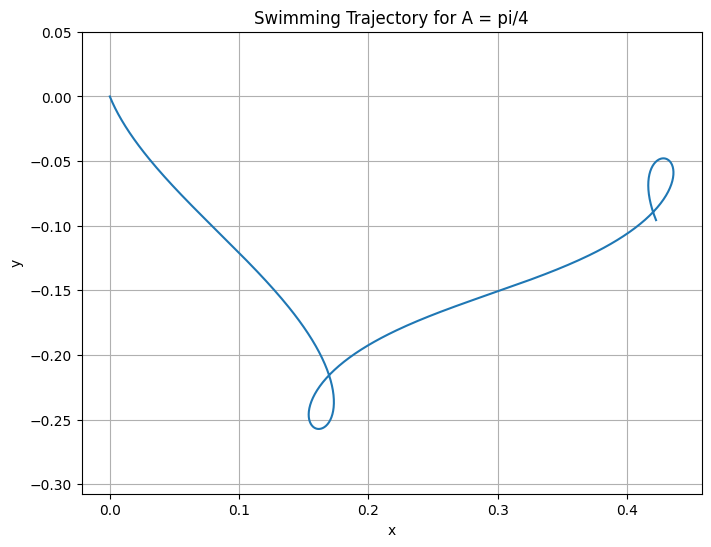

In [24]:
# Part 7 - Simulate Swimming with A = pi/4
# Gait Function
alpha_fcn = lambdify((t, omega, A1, A2, phi),[A1*sin(omega*t),
                                 A2*sin(omega*t +phi),
                                 diff(A1*sin(omega*t),t),
                                 diff(A2*sin(omega*t + phi),t)])
l_=1
k_=1
A_amp = float(pi/4)
A1_ = A_amp
A2_ = A_amp
phi_    = float(np.pi/2)
omega_=float(2*np.pi)
params_ = [l_, k_, A1_, A2_, omega_, phi_]

# Initial conditions [x, y, theta]
y0     = [0, 0, 0]
t_span = (0, 1)
t_eval = np.linspace(0, 1, 500)

# Solve
sol = solve_ivp(
    lambda t, y: dynamics(t, y, alpha_fcn, params_),
    t_span,
    y0,
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-8
)
# Plot x,y trajectory
plt.figure(figsize=(8, 6))
plt.plot(sol.y[0], sol.y[1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Swimming Trajectory for A = pi/4')
plt.axis('equal')
plt.grid(True)
plt.show()

In [29]:
def plot_transform(T, ax):
    origin = T[0:3, 3]
    
    ax.plot([origin[0], T[0,0]+origin[0]], 
            [origin[1], T[1,0]+origin[1]], 
            [origin[2], T[2,0]+origin[2]], 'r')

    ax.plot([origin[0], T[0,1]+origin[0]], 
            [origin[1], T[1,1]+origin[1]], 
            [origin[2], T[2,1]+origin[2]], 'g')
    
    ax.plot([origin[0], T[0,2]+origin[0]], 
            [origin[1], T[1,2]+origin[1]], 
            [origin[2], T[2,2]+origin[2]], 'b')
    
    
def plot_bot(Tb, T1, T2, w_, ax):
    plot_transform(T(eye(3), Matrix([[0], [0], [0]])), ax)

    plot_transform(Tb, ax)
    plot_transform(T1, ax)
    plot_transform(T2, ax)
    
    j1 = Tb @ T(eye(3), Matrix([[-l/2], [0], [0]]))
    j2 = Tb @ T(eye(3), Matrix([[l/2], [0], [0]]))
    e1 = T1 @ T(eye(3), Matrix([[l/2], [0], [0]]))
    e2 = T2 @ T(eye(3), Matrix([[l/2], [0], [0]]))
    
    plt.plot([Tb[0,3], j1[0,3]], [Tb[1,3], j1[1,3]], 'ko-', markersize = 8)
    plt.plot([Tb[0,3], j2[0,3]], [Tb[1,3], j2[1,3]], 'ko-', markersize = 8)
    
    plt.plot([j1[0,3], T1[0,3]], [j1[1,3], T1[1,3]], 'ko-')
    plt.plot([j2[0,3], T2[0,3]], [j2[1,3], T2[1,3]], 'ko-')
    
    plt.plot([e1[0,3], T1[0,3]], [e1[1,3], T1[1,3]], 'ko-')
    plt.plot([e2[0,3], T2[0,3]], [e2[1,3], T2[1,3]], 'ko-')
l_ = 2
w_ = 1
m_ = 1
k_ = 1

A1_ = np.pi/3
A2_ = A1_
omega_ = 2*np.pi
phi_ = np.pi/2 # try 0 it is interesting

params_ = [l_, k_, A1_, A2_, omega_, phi_]

####### x, y, theta, alpha1, alpha2, xdot, ydot, thetadot, alpha1dot, alpha2dot
init_state = [0, 0, -np.pi/8]
t_end = 1
dt = 0.001
time = np.linspace(0,t_end,int(t_end/dt))

sol = solve_ivp(lambda t, y: dynamics(t, y, alpha_fcn, params_),
                [0,t_end], init_state, 
                t_eval = time, 
                rtol=1e-8, atol = 1e-8)

alphas = alpha_fcn(time, params_)
q_dots = sol.y*0

for i, tim in enumerate(time):
    q_temp = dynamics(tim, sol.y[:,i], alpha_fcn, params_)
    q_dots[:,i] = q_temp

x_sol =       sol.y[0,:]
y_sol =       sol.y[1,:]
theta_sol =   sol.y[2,:]

x_dot_sol =       q_dots[0,:]
y_dot_sol =       q_dots[1,:]
theta_dot_sol =   q_dots[2,:]

alpha_0_sol = alphas[0]
alpha_1_sol = alphas[1]
alpha_0_dot_sol = alphas[2]
alpha_1_dot_sol = alphas[2]
fig = plt.figure(2)
fig.clf()
ax = fig.subplots(5, 2, sharex = True)

ax[0][0].plot(time, x_sol)
ax[0][0].set_ylabel('x')
ax[1][0].plot(time, y_sol)
ax[1][0].set_ylabel('y')
ax[2][0].plot(time, theta_sol)
ax[2][0].set_ylabel('theta')
ax[3][0].plot(time, alpha_0_sol)
ax[3][0].set_ylabel('alpha_1')
ax[4][0].plot(time, alpha_1_sol)
ax[4][0].set_ylabel('alpha_2')

ax[0][1].plot(time, x_dot_sol)
ax[0][1].set_ylabel('x_dot')
ax[1][1].plot(time, y_dot_sol)
ax[1][1].set_ylabel('y_dot')
ax[2][1].plot(time, theta_dot_sol)
ax[2][1].set_ylabel('theta_dot')
ax[3][1].plot(time, alpha_0_dot_sol)
ax[3][1].set_ylabel('alpha_dot_1')
ax[4][1].plot(time, alpha_1_dot_sol)
ax[4][1].set_ylabel('alpha_dot_2')
# plt.gcf()

TypeError: _lambdifygenerated() missing 3 required positional arguments: 'A1', 'A2', and 'phi'

### Part 8

In [ ]:
# Part 8 - Sweep Amplitude from 0.1 to 1.2*pi/2
A_vals    = np.linspace(0.1, 1.2*np.pi/2, 50)
distances = []
phi_val   = float(pi/2)

A_vals = np.linspace(0.1, 1.2*np.pi/2, 50)
distances = []

phi_ = float(pi/2)

for A1_ in A_vals:

    # 1. build parameters
    A2_ = A1_
    params_ = [l_, k_, A1_, A2_, omega_, phi_]

    # 2. time setup
    init_state = [0, 0, 0]
    t_end = 1
    dt = 0.01
    time = np.linspace(0, t_end, int(t_end/dt))

    # 3. solve ODE
    sol = solve_ivp(
        lambda t, y: dynamics(t, y, alpha_fcn, params_),
        (0, t_end),
        init_state,
        t_eval=time,
        rtol=1e-8,
        atol=1e-8
    )

    # 4. recompute velocities (like screenshot does)
    q_dots = np.zeros((3, len(time)))

    for i, ti in enumerate(time):
        q_dots[:, i] = dynamics(ti, sol.y[:, i], alpha_fcn, params_)

    # 5. extract final position
    x_sol = sol.y[0, :]
    y_sol = sol.y[1, :]

    d = np.sqrt(x_sol[-1]**2 + y_sol[-1]**2)
    distances.append(d)
# Plot distance vs amplitude
plt.figure(figsize=(8, 6))
plt.plot(A_vals, distances)
plt.xlabel('Amplitude A')
plt.ylabel('Distance Traveled d')
plt.title('Distance Traveled vs Gait Amplitude')
plt.grid(True)
plt.show()

## Problem 2


In [103]:
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff, eye
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import init_printing
init_printing() 

# Define Symbols
t  = symbols("t",   real=True)
l = symbols("l",  positive=True)   # Length of Link, assume Links are same length
#l2 = symbols("l2",  positive=True)   # Length of Link 2
#l3 = symbols("l3",  positive=True)   # Lrngth of link 3
k = symbols("k", positive=True) # Drag Coefficient
# Config Variables
x     = Function('x',     real=True)(t)
y     = Function('y',     real=True)(t)
theta = Function('theta', real=True)(t)
a1    = Function('a1',real=True)(t)
a2    = Function('a2',real=True)(t)
# Defining Various Helper Functions
def cross_matrix(vec):
    
    return Matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return Matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m


### Part 1

In [34]:
def bodywrench_from_Twist(Vb):
    if Vb[3] < 0:
        Vb[3] = 2*Vb[3]
    else: 
        Vb[3] = Vb[3]
    Vb[4] = Vb[4]
    return Vb

In [37]:
Vb=np.array([0,0,0,-3,4,0])
sol=bodywrench_from_Twist(Vb)
sol

array([ 0,  0,  0, -6,  4,  0])

In [41]:
# Body Twist For Each COM
params = [l,k,A1,A2,omega,phi]

Vb1_lam = lambdify([q,q_dt,params],Vb1)
Vb2_lam = lambdify([q,q_dt,params],Vb2)
Vb3_lam = lambdify([q,q_dt,params],Vb3)
# Jacobian
Jb1 = lambdify([q,q_dt,params],Jb1)
Jb2 = lambdify([q,q_dt,params],Jb2)
Jb3 = lambdify([q,q_dt,params],Jb3)

In [42]:
def netforce(x,y,theta,alpha1,alpha2):
    F = Jb1.T @ bodywrench_from_Twist(Vb1) @ Jb1 + \
        Jb2.T @ bodywrench_from_Twist(Vb2) @ Jb2 + \
        Jb3.T @ bodywrench_from_Twist(Vb3) @ Jb3 
    return F


SyntaxError: invalid syntax (1441397009.py, line 2)

### Part 2

In [106]:
# =============================================================================
# CELL 2: Body Jacobians and net generalized force
# =============================================================================

def get_link_transform(q, link_idx, L=1.0):
    """
    World-frame transform T_i for the CENTER of link i,
    built using the T() and R_z() helpers from the setup.
    
    q = [x, y, theta, a1, a2]
    """
    x, y, theta, a1, a2 = q

    # Base frame at origin of link 0
    T_world = T(R_z(theta), Matrix([x, y, 0]))

    # Each joint adds a rotation + translation of length L along x
    T_01 = T(R_z(a1), Matrix([L, 0, 0]))   # joint 1: end of link 0
    T_12 = T(R_z(a2), Matrix([L, 0, 0]))   # joint 2: end of link 1

    # Half-link offset to reach link center
    T_half = T(eye(3), Matrix([L/2, 0, 0]))

    if link_idx == 0:
        T_center = T_world @ T_half
    elif link_idx == 1:
        T_center = T_world @ T_01 @ T_half
    else:
        T_center = T_world @ T_01 @ T_12 @ T_half

    return np.array(T_center.tolist(), dtype=float)


def body_jacobian_link(q, link_idx, L=1.0):
    """
    Body Jacobian J_i (3×5) for link i: maps q_dot → body twist [vx_b, vy_b, omega_b].
    
    Uses get_link_transform() to get R_i and p_i, then builds
    the geometric Jacobian and rotates to body frame via R_i^T.
    """
    q = np.asarray(q, dtype=float)
    x, y, theta, a1, a2 = q

    th0 = theta
    th1 = theta + a1
    th2 = theta + a1 + a2

    # Get this link's world transform
    Ti  = get_link_transform(q, link_idx, L=L)
    Ri  = Ti[:3, :3]          # world ← body rotation (3×3, but planar so use [:2,:2])
    pi  = Ti[:2,  3]          # link center in world frame

    # Joint axes (all z-axis for planar) and joint positions in world frame
    # q = [x, y, theta, a1, a2]
    # Prismatic x:  column 0 → [cos(th0), sin(th0), 0] translated velocity
    # Prismatic y:  column 1 → [0 rotated, sin direction]
    # Revolute theta: about joint at [x,y]
    # Revolute a1:    about joint at end of link 0
    # Revolute a2:    about joint at end of link 1

    # Joint origins in world frame
    p_base = np.array([x, y])
    p_j1   = p_base + L * np.array([np.cos(th0), np.sin(th0)])
    p_j2   = p_j1   + L * np.array([np.cos(th1), np.sin(th1)])

    J_world = np.zeros((3, 5))

    # --- Translational DOFs (x, y): pure prismatic ---
    J_world[0, 0] = 1.0   # d(px)/d(x)
    J_world[1, 1] = 1.0   # d(py)/d(y)

    # --- Revolute DOFs: v = z × (p_i - p_joint), omega = 1 ---
    # z-axis = [0, 0, 1], so z × r = [-ry, rx, 0]
    def revolute_col(p_joint):
        r = pi - p_joint          # vector from joint to link center
        return np.array([-r[1], r[0], 1.0])

    J_world[:, 2] = revolute_col(p_base)                     # theta joint

    if link_idx >= 1:
        J_world[:, 3] = revolute_col(p_j1)                   # a1 joint
    if link_idx >= 2:
        J_world[:, 4] = revolute_col(p_j2)                   # a2 joint

    # Rotate translational rows to body frame: v_b = R^T * v_world
    Rt = Ri[:2, :2].T
    J_body        = np.zeros((3, 5))
    J_body[:2, :] = Rt @ J_world[:2, :]   # rotate xy velocity rows
    J_body[2,  :] = J_world[2,  :]        # angular row unchanged

    return J_body


def net_force_snake_friction(q, q_dot, L=1.0, f_par=1.0, f_lat=2.0):
    """τ = Σ_i J_i^T F_b_i,  where F_b_i = -B * (J_i @ q_dot)"""
    q, q_dot = np.asarray(q, float), np.asarray(q_dot, float)
    return sum(
        body_jacobian_link(q, i, L).T @ body_wrench_from_friction(
            body_jacobian_link(q, i, L) @ q_dot, f_par=f_par, f_lat=f_lat)
        for i in range(3)
    )

# Quick test
q_test     = np.array([0., 0., 0., 0.3, -0.3])
q_dot_test = np.array([0.1, 0., 0., 0.5, -0.5])
print("Cell 2 – net generalized force:")
print("  tau =", net_force_snake_friction(q_test, q_dot_test))

Cell 2 – net generalized force:
  tau = [ 0.03454709 -1.40477261 -4.04378479 -2.63901218 -0.47766824]


### Part 3

In [107]:
# =============================================================================
# CELL 3: Solve for V_P via fsolve
# =============================================================================
from scipy.optimize import fsolve

def swimmer_velocity_fsolve(q, alpha_dot, V_P0=None, L=1.0, f_par=1.0, f_lat=2.0):
    """
    Solve A11 * V_P + A12 * alpha_dot = 0  for V_P = [xdot, ydot, thetadot].
    
    V_P0 : optional warm-start initial guess (pass previous solution in Cell 4)
    """
    q         = np.asarray(q,         float)
    alpha_dot = np.asarray(alpha_dot, float)

    def residual(V_P):
        q_dot = np.concatenate([V_P, alpha_dot])
        return net_force_snake_friction(q, q_dot, L=L, f_par=f_par, f_lat=f_lat)[:3]

    V_P_sol, _, ier, msg = fsolve(residual, np.zeros(3) if V_P0 is None else V_P0,
                                  full_output=True)
    if ier != 1:
        print(f"  fsolve warning: {msg}")
    return V_P_sol


# Test on random config
np.random.seed(42)
q_rand    = np.array([0., 0., np.random.uniform(-np.pi, np.pi),
                      np.random.uniform(-1., 1.), np.random.uniform(-1., 1.)])
adot_rand = np.random.uniform(-1., 1., size=2)

V_P = swimmer_velocity_fsolve(q_rand, adot_rand)
print("Cell 3 – swimmer velocity (fsolve)")
print(f"  V_P   = {V_P}")
print(f"  residual = {net_force_snake_friction(np.concatenate([q_rand]), np.concatenate([V_P, adot_rand]))[:3]}")

Cell 3 – swimmer velocity (fsolve)
  V_P   = [-0.04856174 -0.1203313   0.0759871 ]
  residual = [ 1.38777878e-17 -5.37764278e-17  0.00000000e+00]


### Part 4

In [ ]:
# =============================================================================
# CELL 4: Dynamics + solve_ivp
# =============================================================================

def make_dynamics(omega=1.0, A=0.5, L=1.0, f_par=1.0, f_lat=2.0):
    """
    Returns a dynamics function with a warm-start cache — passes the
    previous V_P solution as the initial guess to fsolve each step.
    """
    V_P_cache = [np.zeros(3)]

    def dynamics(t, state):
        q  = np.asarray(state, float)
        th = q[2]

        alpha_dot = np.array([
            A * omega * np.cos(omega * t),
            A * omega * np.cos(omega * t + np.pi / 2)
        ])

        V_P = swimmer_velocity_fsolve(q, alpha_dot,
                                      V_P0=V_P_cache[0], L=L,
                                      f_par=f_par, f_lat=f_lat)
        V_P_cache[0] = V_P   # update warm-start

        return [V_P[0], V_P[1], V_P[2], alpha_dot[0], alpha_dot[1]]

    return dynamics


A, omega, t_end = 0.5, 2.0, 10.0
state0 = [0., 0., 0., 0., 0.]

sol = solve_ivp(make_dynamics(omega=omega, A=A),
                t_span=(0, t_end), y0=state0,
                method='RK45', max_step=0.05, rtol=1e-4, atol=1e-6)
print(f"Integration {'succeeded' if sol.success else 'FAILED'}: {sol.message}")

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle("3-Link Snake Locomotion (Snake-Skin Friction)", fontsize=13, fontweight='bold')
t_arr = sol.t
x, y, theta, a1, a2 = sol.y

axes[0,0].plot(x, y, 'steelblue', lw=2)
axes[0,0].plot(x[0], y[0], 'go', ms=8, label='start')
axes[0,0].plot(x[-1], y[-1], 'rs', ms=8, label='end')
axes[0,0].set(xlabel='x (m)', ylabel='y (m)', title='Trajectory', aspect='equal')
axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(t_arr, np.rad2deg(theta), color='darkorange', lw=2)
axes[0,1].set(xlabel='time (s)', ylabel='theta (deg)', title='Base Heading')
axes[0,1].grid(True)

axes[1,0].plot(t_arr, np.rad2deg(a1), label='α₁', color='royalblue', lw=2)
axes[1,0].plot(t_arr, np.rad2deg(a2), label='α₂', color='tomato', lw=2, ls='--')
axes[1,0].set(xlabel='time (s)', ylabel='angle (deg)', title='Joint Angles')
axes[1,0].legend(); axes[1,0].grid(True)

speed = np.sqrt(np.gradient(x, t_arr)**2 + np.gradient(y, t_arr)**2)
axes[1,1].plot(t_arr, speed, color='mediumseagreen', lw=2)
axes[1,1].set(xlabel='time (s)', ylabel='speed (m/s)', title='Translational Speed')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()